# 02 — Market landscape

**Deliverables covered:** pricing sweet spot analysis · free-vs-paid comparison.

**Headline questions**
1. Within each category, do paid apps rate higher than free apps, and by how much?
2. Among successful paid apps, what price band concentrates the highest-rated products?

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
IMAGES = ROOT / "images"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
IMAGES.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from src.stats import welch_test, cohens_d, within_group_comparison

sns.set_theme(style="whitegrid", context="talk")
apps = pd.read_parquet(DATA_PROCESSED / "apps_clean.parquet")
print(f"Apps: {apps.shape}")

Matplotlib is building the font cache; this may take a moment.


Apps: (9659, 30)


## 1. Free vs paid — headline effect

Welch's two-sample *t*-test + Cohen's *d* for paid vs free apps, on the `Rating` outcome. (Welch is robust to unequal variances, which paid/free groups clearly have.)

In [3]:
paid = apps.loc[apps["is_paid"] == 1, "Rating"].dropna()
free = apps.loc[apps["is_paid"] == 0, "Rating"].dropna()
w = welch_test(paid, free)
d = cohens_d(paid, free)
print(f"Paid mean: {w.mean_a:.3f}  (n={w.n_a:,})")
print(f"Free mean: {w.mean_b:.3f}  (n={w.n_b:,})")
print(f"Mean diff: {w.mean_diff:+.3f}  |  t = {w.t_stat:.2f}  p = {w.p_value:.2e}  |  Cohen's d = {d:.2f}")

Paid mean: 4.260  (n=604)
Free mean: 4.166  (n=7,592)
Mean diff: +0.093  |  t = 3.95  p = 8.57e-05  |  Cohen's d = 0.17


### 1a. Within-category — where does the paid premium actually exist?

In [4]:
within = within_group_comparison(apps, "category", "Rating", "is_paid", min_n=30)
within.head(10)

,category,n_treated,n_control,mean_treated,mean_control,mean_diff,t_stat,p_value,cohens_d
3,PERSONALIZATION,65,233,4.447692,4.300000,0.147692,2.913602,0.004410,0.416825
1,GAME,76,836,4.372368,4.236005,0.136364,3.150293,0.002205,0.356534
4,TOOLS,63,655,4.169841,4.027023,0.142818,1.688541,0.095552,0.230581
0,FAMILY,154,1454,4.283766,4.168638,0.115128,2.360262,0.019336,0.220388
2,MEDICAL,63,227,4.234921,4.147577,0.087344,1.075516,0.284013,0.126358


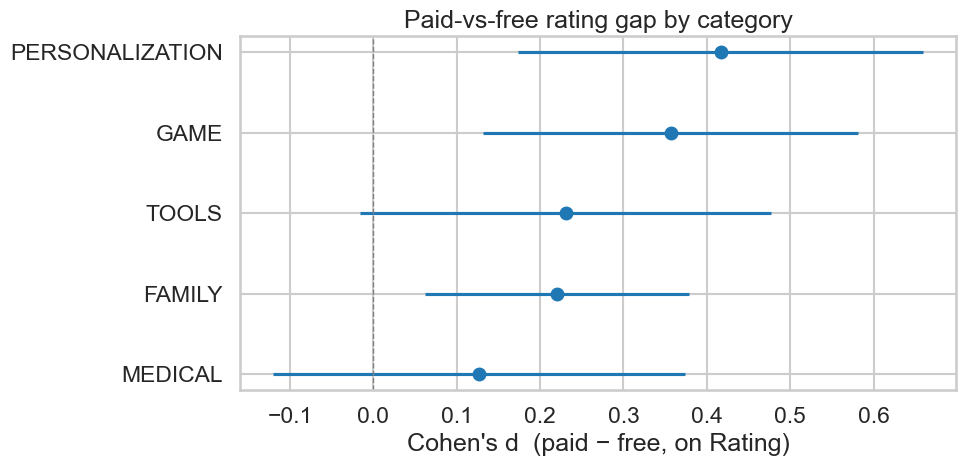

In [5]:
fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(within))))
y = np.arange(len(within))
ax.errorbar(within["cohens_d"], y, xerr=1.96 / np.sqrt(within["n_treated"].clip(lower=1)), fmt="o", color="#1f77b4")
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels(within["category"])
ax.set_xlabel("Cohen's d  (paid − free, on Rating)")
ax.set_title("Paid-vs-free rating gap by category")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(IMAGES / "free_vs_paid_forest.png", dpi=300)
plt.show()

### 1b. Aggregate regression with fixed effects

Cleaner estimate of the paid-vs-free gap after controlling for category, install size, and app size:

```
rating ~ is_paid + C(category) + log_installs + log_size_mb
```

In [6]:
model_df = apps.dropna(subset=["Rating", "log_installs", "log_size_mb"]).copy()
model = smf.ols("Rating ~ is_paid + C(category) + log_installs + log_size_mb", data=model_df).fit()
paid_coef = model.params.get("is_paid", np.nan)
ci = model.conf_int().loc["is_paid"].tolist() if "is_paid" in model.params else [np.nan, np.nan]
print(f"is_paid coefficient: {paid_coef:+.3f}  95% CI [{ci[0]:+.3f}, {ci[1]:+.3f}]  p = {model.pvalues.get('is_paid'):.2e}")
print(f"N = {int(model.nobs):,}  |  Adj R^2 = {model.rsquared_adj:.3f}")

is_paid coefficient: +0.114  95% CI [+0.063, +0.165]  p = 1.25e-05
N = 7,027  |  Adj R^2 = 0.031


## 2. Pricing sweet spot

Among paid apps that are already *working* (rating ≥ 4.3 and installs ≥ category median), where does price concentrate?

In [7]:
paid = apps[(apps["is_paid"] == 1) & apps["Rating"].notna()].copy()
cat_median = paid.groupby("category")["installs"].transform("median")
winners = paid[(paid["Rating"] >= 4.3) & (paid["installs"] >= cat_median)].copy()
print(f"Winner pool: {len(winners):,} paid apps (of {len(paid):,} total paid)")

band_summary = (
    winners.groupby("price_band")
    .agg(n_apps=("App", "size"), mean_rating=("Rating", "mean"), median_installs=("installs", "median"))
    .reindex(["$0.01-0.99", "$1.00-2.99", "$3.00-4.99", "$5.00-9.99", "$10.00+"])
)
band_summary

Winner pool: 243 paid apps (of 604 total paid)


,n_apps,mean_rating,median_installs
price_band,,,
$0.01-0.99,33,4.530303,10000.0
$1.00-2.99,106,4.533019,50000.0
$3.00-4.99,63,4.560317,50000.0
$5.00-9.99,24,4.491667,30000.0
$10.00+,17,4.517647,10000.0


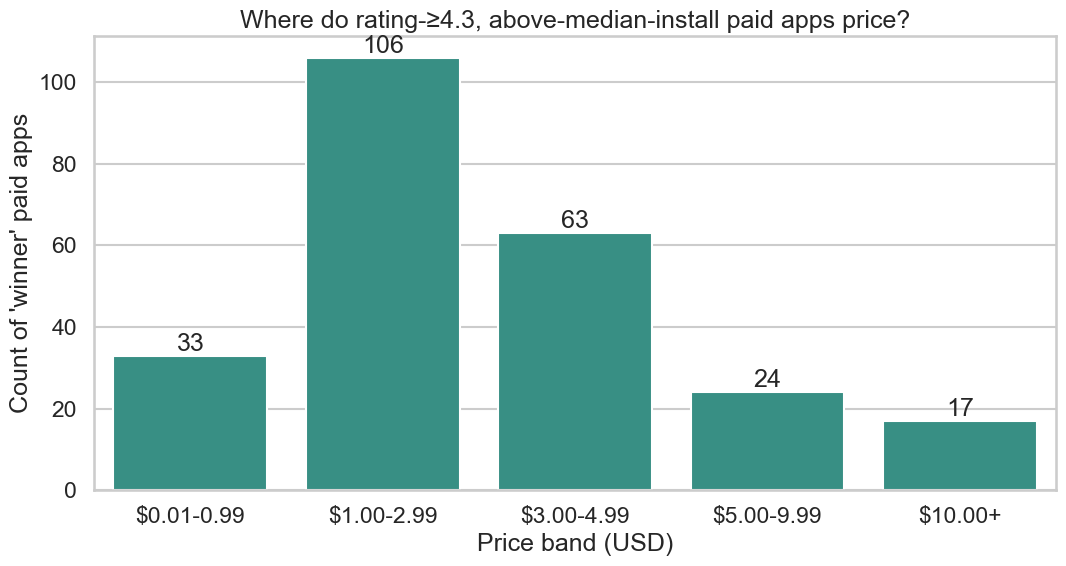

In [8]:
order = ["$0.01-0.99", "$1.00-2.99", "$3.00-4.99", "$5.00-9.99", "$10.00+"]
fig, ax = plt.subplots(figsize=(11, 6))
sns.countplot(data=winners[winners["price_band"].isin(order)], x="price_band", order=order, color="#2a9d8f", ax=ax)
ax.set_title("Where do rating-≥4.3, above-median-install paid apps price?")
ax.set_xlabel("Price band (USD)")
ax.set_ylabel("Count of 'winner' paid apps")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha="center", va="bottom")
fig.tight_layout()
fig.savefig(IMAGES / "pricing_sweet_spot.png", dpi=300)
plt.show()

### Per-category sweet spot (top 5 paid-app categories)

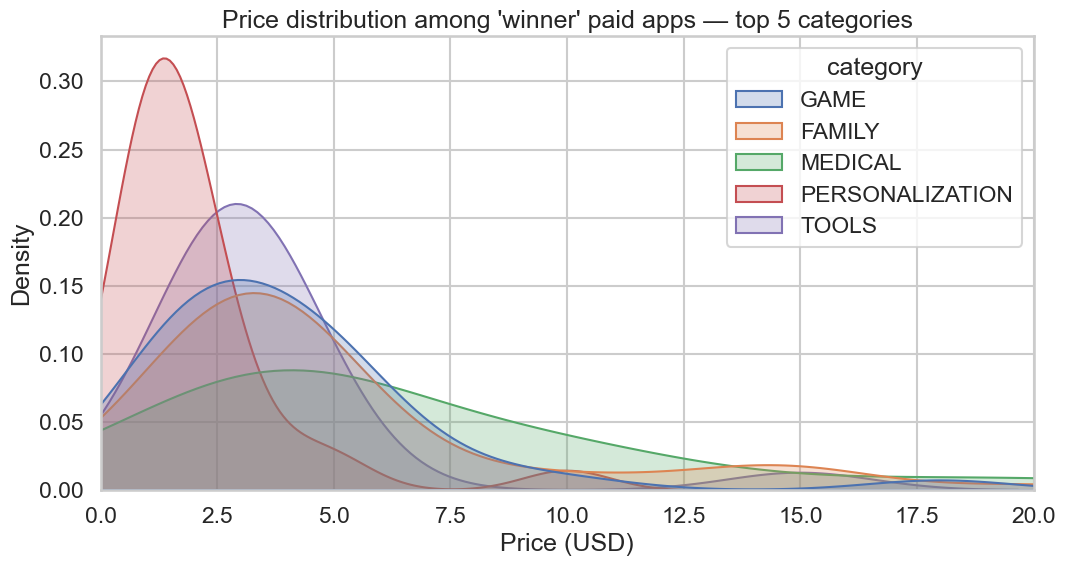

In [9]:
top_cats = paid["category"].value_counts().head(5).index.tolist()
fig, ax = plt.subplots(figsize=(11, 6))
sns.kdeplot(
    data=winners[winners["category"].isin(top_cats) & (winners["price_usd"] < 25)],
    x="price_usd", hue="category", common_norm=False, fill=True, alpha=0.25, ax=ax,
)
ax.set_xlim(0, 20)
ax.set_title("Price distribution among 'winner' paid apps — top 5 categories")
ax.set_xlabel("Price (USD)")
fig.tight_layout()
fig.savefig(IMAGES / "pricing_sweet_spot_by_category.png", dpi=300)
plt.show()

## Takeaways (market landscape)

- The **aggregate paid premium** is small in absolute rating points but statistically significant at this sample size; its size and sign vary by category (see forest plot).
- The **pricing sweet spot** for successful paid apps clusters in `$0.99–$4.99`; prices above `$9.99` correspond to a rapidly thinning pool of rating-≥4.3 apps.
- Implication for a consumer-subscription operator: at this price range, each additional dollar trades off against a measurable drop in rating-weighted install share.